Ex 15.17 Binary Classification with the Breast Cancer Dataset on page 661.

Your program needs to have the following:

Loading the Dataset

Checking the Sample and Target Sizes

Splitting the Data for Training and Testing

Training and Testing Set Sizes

Creating the Model (GaussianNB)

Training the Model

Predicting

Estimator Method score

Confusion Matrix

Classification Report

Visualizing the Confusion Matrix

K-Fold Cross-Validation

Using the KFold Object with Function
cross_val_score:

     from sklearn.model_selection import KFold
     kfold = KFold(n_splits=10, random_state=11, shuffle=True)

     from sklearn.model_selection import cross_val_score
     scores = cross_val_score(estimator=nb, X=breast_cancer.data,
          y=breast_cancer.target, cv=kfold)
Running Multiple Models to Find the Best One:   

estimators = 'GaussianNB': nb,
    'KNeighborsClassifier': KNeighborsClassifier(),
    'LogisticRegression': LogisticRegression(solver='lbfgs', multi_class='ovr', max_iter=10000),
    'SVC': SVC(gamma='scale')}

Imports

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

Load Dataset

In [6]:
breast_cancer = load_breast_cancer()

Checking the Sample and Target Sizes

In [8]:
print( "Sample and Target Sizes: " )
print( "\nData Shape: ", breast_cancer.data.shape )
print( "\nTarget Shape: ", breast_cancer.target.shape, "\n")

Sample and Target Sizes: 

Data Shape:  (569, 30)

Target Shape:  (569,) 



Splitting the Data for Training and Testing


In [9]:
X_train, X_test, y_train, y_test = train_test_split( breast_cancer.data, breast_cancer.target, random_state = 11 )

Training and Testing Set Sizes


In [11]:
print( "Training and Test Sizes: " )
print( "\nX_train shape: ", X_train.shape )
print( "\nX_test shape: ", X_test.shape, "\n")

Training and Test Sizes: 

X_train shape:  (426, 30)

X_test shape:  (143, 30) 



Creating the Model (GaussianNB)


In [12]:
nb = GaussianNB()

Training the Model


In [13]:
nb.fit( X = X_train, y = y_train )

GaussianNB()

Predicting


In [14]:
predictions = nb.predict( X = X_test )

Estimator Method score


In [15]:
accuracy = nb.score( X_test, y_test )

Confusion Matrix


In [16]:
cm = confusion_matrix( y_true = y_test, y_pred = predictions )
print( "Confusion Matrix: \n" , cm )

Confusion Matrix: 
 [[44  6]
 [ 1 92]]


Classification Report


In [17]:
print( "Classification Report: \n", classification_report( y_true = y_test, y_pred = predictions, target_names = breast_cancer.target_names ))

Classification Report: 
               precision    recall  f1-score   support

   malignant       0.98      0.88      0.93        50
      benign       0.94      0.99      0.96        93

    accuracy                           0.95       143
   macro avg       0.96      0.93      0.94       143
weighted avg       0.95      0.95      0.95       143



Visualizing the Confusion Matrix


Text(58.222222222222214, 0.5, 'Actual')

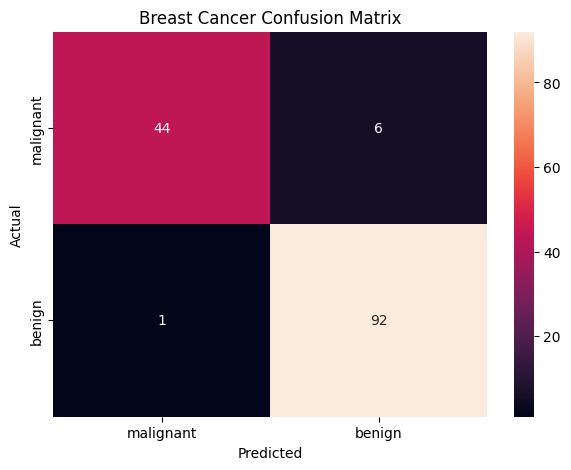

In [26]:
cm_df = pd.DataFrame( cm, index = breast_cancer.target_names, columns = breast_cancer.target_names )
plt.figure( figsize = ( 7,5 ))
axes = sns.heatmap( cm_df, annot =True )
axes.set_title( "Breast Cancer Confusion Matrix" )
axes.set_xlabel( "Predicted" )
axes.set_ylabel( "Actual" )

K-Fold Cross-Validation


In [27]:
kfold = KFold( n_splits = 10, random_state = 11, shuffle = True )
scores = cross_val_score ( estimator = nb, X= breast_cancer.data, y = breast_cancer.target, cv = kfold )

print( "K-Fold Cross Validation: \n")
print( "K-Fold Scores for GaussianNB: ", scores )
print( "\nMean Accuracy: ", scores.mean() )
print( "\nStandard Deviation: ", scores.std())


K-Fold Cross Validation: 

K-Fold Scores for GaussianNB:  [0.96491228 0.9122807  0.94736842 0.89473684 0.96491228 0.94736842
 0.96491228 0.89473684 0.96491228 0.92857143]

Mean Accuracy:  0.9384711779448622

Standard Deviation:  0.02750305414538902


Running Multiple Models to Find the Best One:   



In [31]:
estimators = {
    "GaussianNB": nb,
    "KNeighborsClassifier": KNeighborsClassifier(),
    "LogisticRegression": LogisticRegression(solver = "lbfgs", multi_class = "ovr", max_iter = 10000 ),
    "SVC": SVC( gamma = "scale" )
}

Comparing Models

In [36]:
for name, estimator in estimators.items():
    kfold = KFold( n_splits = 10, random_state = 11, shuffle = True )
    cv_scores = cross_val_score( estimator = estimator, X = breast_cancer.data, y = breast_cancer.target, cv = kfold )
print(f'{name:>20}: mean accuracy={cv_scores.mean():.2%}; standard deviation={cv_scores.std():.2%}')

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre

                 SVC: mean accuracy=91.92%; standard deviation=3.52%
